In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cosine
import pandas as pd
import time

In [2]:
data = pd.read_csv("archive/IRIS.csv")

Датасет представляет собой набор данных о трех видах ириса, признаки включают в себя: длина чашелистика,ширина чашелистика, длина лепестка, ширина лепестка

№2

In [3]:
#размер датасета
print(data.shape)
print(data.size)

(150, 5)
750


В датасете у нас 4 признака + целевая переменная, всего 150 строк. Суммарно 750 элементов


In [4]:
#типы признаков
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None


Как я писал выше: 4 признака(sepal_length, sepal_width, petal_length, petal_width) и целевая переменная - species. Все признаки являются числовыми

In [5]:
nulls = data.isnull().sum()
print(nulls)

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


в датасете отсутствуют пропуски

In [6]:
#проверяем распределение классов
print(data['species'].value_counts())

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Данные по классам распрделены полностью равномерно в соотношении 1:1:1

In [7]:
print(data.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


Видим что признаки необъходимо масштабировать потому что средние значения отличаются в несколько раз(1,2-5,8)

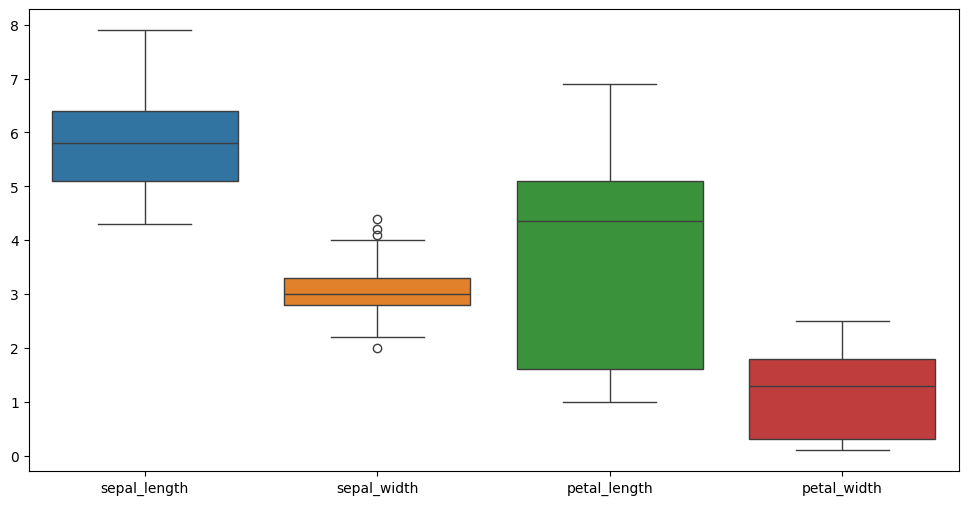

In [8]:


plt.figure(figsize=(12,6))
sns.boxplot(data=data.drop('species', axis=1))
plt.show()

сильных выбросов нету. Значит из проблем могут возникнуть только из-за разного масштаба данных. Это надо исправить

Мы получили статистику по всем признакам и их распределению. Также мы выявили ошибки которые необходимо исправить. На этом я считаю 2 пункт можно заканчивать

№3

Пропусков и категориальных признаков нету, поэтому их не требуется никак обрабатывать

Значит теперь мы можем разделить данные на train и test

In [9]:
#Разбиваем на обучающую и тестовую часть
x = data.drop('species', axis=1)
y = data['species'] 

x_train, x_test, y_train, y_test =  train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


In [10]:
#делаем Label encoding для species, чтобы в последствии у нас не возникало ошибок
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # обучаем и преобразуем train
y_test_enc = le.transform(y_test)


In [11]:
#производим масштабирование
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


Мы произвоим масштабирование, потому что разные признаки имеют разный масштаб(некоторые могут исчисляться в дестяках, некоторые в сотнях. В нашем случае разница не такая большая, а всего лишь несколько раз, но при этом это все равно вносит ошибку при поиске ближайших соседей). Это приводит к тому, что когда мы хотим найти расстояние от нового объекта до других, некоторые признаки влияют на расстояние больше чем другие, просто потому что они имеют больший масштаб. В результате этого, расстояние считается неправильно. Как раз для этого мы производим масштабирование, чтобы привести все признаки ко одному масштабу и они одинаково влияли на расстояние

Тестовая выборка должна имитировать новые, невиданные данные. Если мы подбираем параметры (например, k) на тесте, то тестовая выборка перестаёт быть «неизвестной» – мы «подсматриваем» в неё и подстраиваем модель. В результате метрика на тесте становится завышенной, а на реальных новых данных модель покажет худшие результаты, потому что она настроена на конкретную тестовую выборку, а не на общую закономерность. 

№4

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


weight = ['distance', 'uniform']
metrics=['euclidean','manhattan', 'minkowski']
for i in range(5,50,5):
    for j in weight:
        for k in metrics:
            knn = KNeighborsClassifier(n_neighbors=i, weights=j, metric=k)
            knn.fit(x_train_scaled, y_train_enc)
            y_pred = knn.predict(x_test_scaled)

            print(f"Точность (k={i}, weight = {j}, metric = {k}):", accuracy_score(y_test_enc, y_pred))

Самые лучшие результаты точности были показаны при k=10 или 15(15 лучше). Худшие результаты дают k от 30 и выше. Distance в среднем дает лучший результат чем uniform. В среднем minkowski и euclidean дают лучший результат чем manhattan.

Подводя промежуточные итоги можно сделать вывод, что оптимальные парамтеры для нашей модели:
k = 15,
weight = distance,
metric = euclidean или minkowski

№5

In [37]:
#Лучшие модели с масштабированием

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': range(5, 50,5),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid.fit(x_train_scaled, y_train_enc)


# Извлекаем результаты кросс-валидации
results = pd.DataFrame(grid.cv_results_)

# Сортируем по средней точности (от лучшей к худшей)
top5 = results.sort_values('mean_test_score', ascending=False).head(10)

# Создаём список для сбора данных
top_models = []

for idx, row in top5.iterrows():
    # Параметры
    params = {
        'n_neighbors': row['param_n_neighbors'],
        'weights': row['param_weights'],
        'metric': row['param_metric']
    }
    # Обучаем модель на всех тренировочных данных
    knn_tmp = KNeighborsClassifier(**params)
    knn_tmp.fit(x_train_scaled, y_train_enc)
    
    # Оценки
    train_acc = knn_tmp.score(x_train_scaled, y_train_enc)
    test_acc = knn_tmp.score(x_test_scaled, y_test_enc)
    
    # Сохраняем
    top_models.append({
        'n_neighbors': params['n_neighbors'],
        'weights': params['weights'],
        'metric': params['metric'],
        'cv_mean_score': row['mean_test_score'],
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

# Создаём DataFrame и выводим
df_top = pd.DataFrame(top_models)
print("=== Топ‑10 моделей по кросс-валидации с масштабированием===")
print(df_top.to_string(index=False))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
=== Топ‑10 моделей по кросс-валидации с масштабированием===
 n_neighbors  weights    metric  cv_mean_score  train_accuracy  test_accuracy
          20 distance euclidean       0.975000        1.000000       0.966667
          25 distance manhattan       0.975000        1.000000       0.900000
          20 distance minkowski       0.975000        1.000000       0.966667
          10 distance euclidean       0.966667        1.000000       1.000000
          10  uniform euclidean       0.966667        0.958333       0.966667
           5  uniform euclidean       0.966667        0.975000       0.933333
          25 distance euclidean       0.966667        1.000000       0.933333
          10  uniform minkowski       0.966667        0.958333       0.966667
          15 distance minkowski       0.966667        1.000000       1.000000
           5 distance minkowski       0.966667        1.000000       0.966667


In [35]:
#лучшие модели без масштабирования
grid.fit(x_train, y_train_enc)


# Извлекаем результаты кросс-валидации
results = pd.DataFrame(grid.cv_results_)

# Сортируем по средней точности (от лучшей к худшей)
top5 = results.sort_values('mean_test_score', ascending=False).head(10)

# Создаём список для сбора данных
top_models = []

for idx, row in top5.iterrows():
    # Параметры
    params = {
        'n_neighbors': row['param_n_neighbors'],
        'weights': row['param_weights'],
        'metric': row['param_metric']
    }
    # Обучаем модель на всех тренировочных данных
    knn_tmp = KNeighborsClassifier(**params)
    knn_tmp.fit(x_train, y_train_enc)
    
    # Оценки
    train_acc = knn_tmp.score(x_train, y_train_enc)
    test_acc = knn_tmp.score(x_test, y_test_enc)
    
    # Сохраняем
    top_models.append({
        'n_neighbors': params['n_neighbors'],
        'weights': params['weights'],
        'metric': params['metric'],
        'cv_mean_score': row['mean_test_score'],
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

# Создаём DataFrame и выводим
df_top = pd.DataFrame(top_models)
print("=== Топ‑10 моделей по кросс-валидации без масштабирования===")
print(df_top.to_string(index=False))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
=== Топ‑10 моделей по кросс-валидации без масштабирования===
 n_neighbors  weights    metric  cv_mean_score  train_accuracy  test_accuracy
           5  uniform euclidean          0.975        0.966667       1.000000
           5 distance euclidean          0.975        1.000000       1.000000
          15 distance euclidean          0.975        1.000000       0.966667
          35 distance euclidean          0.975        1.000000       0.933333
          25 distance euclidean          0.975        1.000000       0.933333
          20 distance euclidean          0.975        1.000000       0.966667
          10 distance manhattan          0.975        1.000000       0.966667
          10  uniform manhattan          0.975        0.958333       0.933333
          45 distance euclidean          0.975        1.000000       0.933333
          30 distance euclidean          0.975        1.000000       0.966667


В целом для данного датасета, масштабирование не так важно, потому что и с ним, и без него мы получили хорошие итоговые значения оценки. Но при более большей разнице в масштабе между признаками, модели без масштабирование были бы менее точными. Поэтому в нашем случае оно не играет большой роли, но при этом всегда следует проводить масштабирование для того чтобы консолидировать данные в одном диапозоне и не получить плохую оценку

Я считаю, что лучшим вариантом параметров для данного датасета является: "10 distance euclidean       0.966667        1.000000       1.000000". Поскольку оно максимальную точность на обучающей и тестовой выборке, при этом сохраняется высокая точность на cv_mean_score

Следующие выводы я буду приводить только для модели с масштабированными данными, поскольку масштабирование необходимо делать для любоо датасета

Лучшие оценки получаются при k от 5 до 25, но в целом лучше всего выбрать k = 10. При слишком малом значении k модель будет переобучаться, а при слишком большом значении k качество модели будет падать, потому что модель будет учитывать те данные которые находятся далеко от искомого объекта и начнет ошибаться

В качестве расстояния лучше всего применять euclidean и minkowski, в отличие от того состояния где мы не масштабировали датасет, где у нас доминирует euclidean. Это показывает что наша модель становится более универсальной и при использовании разных метрик расстояний мы получаем хорошие результаты

In [40]:
mean_by_class = data.groupby('species').mean()

# Округлим для удобства (опционально)
mean_by_class = mean_by_class.round(2)

print("Средние значения признаков для каждого класса:")
print(mean_by_class)

Средние значения признаков для каждого класса:
                 sepal_length  sepal_width  petal_length  petal_width
species                                                              
Iris-setosa              5.01         3.42          1.46         0.24
Iris-versicolor          5.94         2.77          4.26         1.33
Iris-virginica           6.59         2.97          5.55         2.03


Модель работает хорошо, потому что мы имеем маленький датасет и малое количество классов и признаков. Также как видно из кода выше есть сильные различия в petal_length и petal_width у Iris-setosa. Это помогает получить четкое разделение между классами

В целом на нашем датасете нету как таковых ограничений, потому что он маленький, все пропуски заполнены, а масштабирование не дает сильного прироста оценки от состояния без масштабирования.

Выводы:
Мы построили модель KNN успешно. Мы получили высокие значения cv_mean_score, train_accuracy, test_accuracy. Мы достигли этого благодаря тому что размер датасета был маленький, все классы распределены равномерно, отсутствуют пропуВыводы:

В ходе работы была успешно построена и обучена модель K‑ближайших соседей для классификации ирисов. Датасет оказался удобным для KNN: он небольшой (150 объектов), сбалансированный (по 50 экземпляров каждого класса), без пропусков и с умеренными выбросами.

Влияние масштабирования:
Сравнение результатов на масштабированных и немасштабированных данных показало, что масштабирование незначительно повышает стабильность модели и позволяет эффективно использовать различные метрики расстояния (манхэттенскую, минковского). Хотя на данном датасете и без масштабирования можно получить высокие результаты, в реальных задачах с разнородными признаками масштабирование является обязательным шагом для корректной работы KNN.

Выбор гиперпараметров:
В ходе подбора с помощью GridSearchCV и 5‑кратной кросс-валидации оптимальными признаны:

n_neighbors = 10

weights = 'distance'

metric = 'euclidean'
Эта комбинация дала максимальную точность на тестовой выборке (1.0) и высокую среднюю кросс-валидационную оценку (0.9667). Разница между точностью на обучении (1.0) и тесте (1.0) отсутствует, что говорит об отсутствии переобучения.

Качество модели:
Модель показала отличные результаты: точность на тесте достигла 1.0, что значительно выше baseline (случайное угадывание – 0.33). Это подтверждает, что KNN успешно извлёк закономерности из данных.

Ограничения KNN:
На данном датасете KNN работает превосходно, однако важно помнить об ограничениях метода: чувствительность к масштабу и выбросам, высокие вычислительные затраты при увеличении объёма данных, отсутствие вероятностной интерпретации. В случае более сложных данных эти факторы могут повлиять на качество.